--- Dataset Sample ---


,customer,category,answers,language
0,How much does Phone charger cost?,Mobile Phones,"Phone charger costs TZS 13,000 per piece. We h...",English
1,"Je, Mafuta ya kupikia lita 20 inapatikana Zanz...",Vyakula na Vinywaji,"Bei ya Mafuta ya kupikia lita 20 ni TZS 80,500...",Kiswahili
2,Naomba mnithibitishie bei ya sasa ya Kreti la ...,Vyakula na Vinywaji,"Bei ya Kreti la soda Azam ni TZS 16,000. Bidha...",Kiswahili
3,Is Irrigation pipe (per meter) available in Mw...,Agriculture & Livestock,Irrigation pipe (per meter) is available at TZ...,English
4,What is the price of USB flash drive 32GB?,"Computers, IT & Office","Yes, USB flash drive 32GB is in stock. The pri...",English



--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   customer  20000 non-null  str  
 1   category  20000 non-null  str  
 2   answers   20000 non-null  str  
 3   language  20000 non-null  str  
dtypes: str(4)
memory usage: 625.1 KB

--- Top Query Categories ---
category
Viatu na Mikoba                        765
Shoes & Bags                           759
Kompyuta, TEHAMA na Ofisi              744
Magari na Vipuri                       743
Kilimo na Mifugo                       739
Mobile Phones                          736
Food & Beverages                       734
Afya na Dawa                           729
Agriculture & Livestock                728
Mifuko ya Intaneti na Salio            727
Cosmetics & Personal Care              724
Home Appliances & Electronics          721
Vipodozi na Usafi wa Mwili             719
Computers, IT & Office    

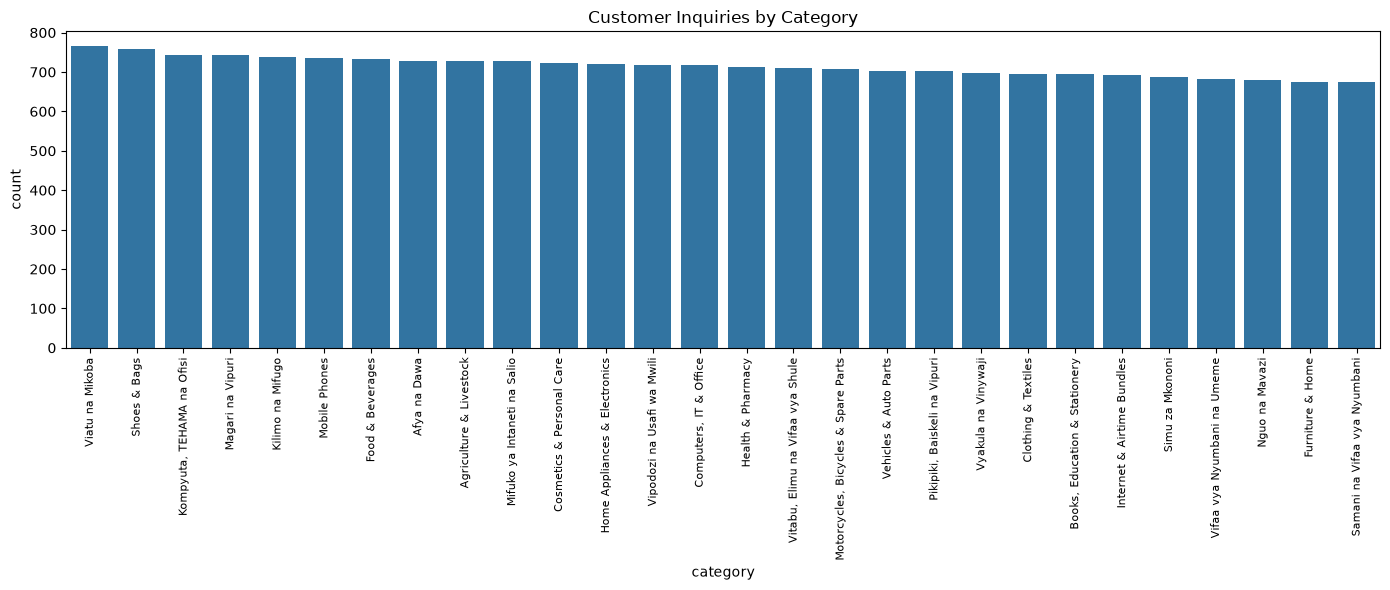

In [3]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

# Load dataset (e.g., customer support logs or feedback)
df = pd.read_csv(r"C:\Users\Miss Jessy\OneDrive\Desktop\Mteja-AI\backend\app\data\mteja_ai_tanzania_dataset.csv")

# 1. Inspect first few rows
print("--- Dataset Sample ---")
display(df.head())

# 2. Check missing values and data types
print("\n--- Data Info ---")
df.info()

# 3. Analyze top customer query categories
print("\n--- Top Query Categories ---")
category_counts = df['category'].value_counts()
print(category_counts)

# 4. Plot distribution of inquiries
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='category', order=df['category'].value_counts().index)
plt.title("Customer Inquiries by Category")
plt.xticks(rotation=90, ha='center', fontsize=8)
plt.tight_layout()
plt.show()

In [5]:

# 2. Preprocess & Clean
text_col = 'question' if 'question' in df.columns else 'answers'
target_col = 'category'

df = df.dropna(subset=[text_col, target_col])
X = df[text_col].astype(str).str.lower().str.strip()
y = df[target_col]

# 3. Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 4. Define & Train Model Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),  # Supports Swahili and English n-grams
    ('classifier', MultinomialNB(alpha=0.1))
])

print("Training model...")
pipeline.fit(X_train, y_train)

# 5. Evaluate Accuracy
y_pred = pipeline.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_pred))

# 6. Save Trained Artifact
output_dir = r"C:\Users\Miss Jessy\OneDrive\Desktop\Mteja-AI\backend\app\ml_models"
os.makedirs(output_dir, exist_ok=True)
model_path = os.path.join(output_dir, "mteja_category_classifier.pkl")

joblib.dump(pipeline, model_path)
print(f"Saved trained model to: {model_path}")

Training model...
Model Accuracy: 99.40%

                                     precision    recall  f1-score   support

                       Afya na Dawa       1.00      1.00      1.00       146
            Agriculture & Livestock       1.00      0.99      1.00       145
      Books, Education & Stationery       1.00      0.99      0.99       139
                Clothing & Textiles       0.99      1.00      1.00       139
             Computers, IT & Office       0.99      1.00      1.00       144
          Cosmetics & Personal Care       1.00      1.00      1.00       145
                   Food & Beverages       1.00      1.00      1.00       147
                   Furniture & Home       1.00      0.99      1.00       135
                  Health & Pharmacy       1.00      1.00      1.00       143
      Home Appliances & Electronics       1.00      1.00      1.00       144
         Internet & Airtime Bundles       1.00      1.00      1.00       138
                   Kilimo na Mifu